# Week 11 - Unsupervised Learning
#### Part 2
### Notebook created by Jonathan Penava
By the end of this lesson you would have covered various concepts of unsupervised learning.

## Overview
- Unsupervised Learning
- <span style="color:red;">Image Reduction</span>

In our code example we are going to look at performing an image reduction using K-Means clustering, moving from a higher 24 bit color bit image to a lower 4 bit one.  This can be useful for storage space if the high quality image isn't needed.  Credit to Simplilearn for the example https://www.youtube.com/watch?v=teWYOMn9Lso&t=16984s 

We are going to start with our standard set of imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


We are then going to load in a default image from sklearn of a flower.

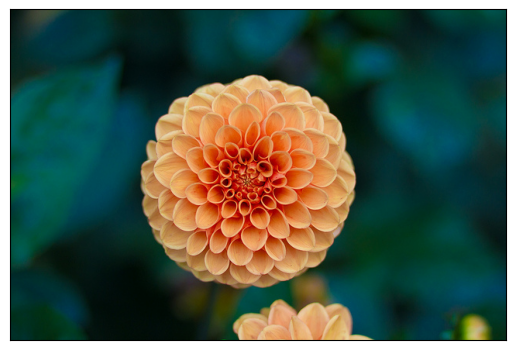

In [41]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower)

Alternatively you could try this with your own image by using <br>
<code>
from skimage import io<br>
img = io.imread('myimage.png')
</code>

If we look at the 'shape' of our image

In [42]:
flower.shape

(427, 640, 3)

We get a triple of our height, width, and color dimension which is RGB.

Trying to examine our image more closely

In [43]:
flower

array([[[ 2, 19, 13],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 1, 77, 64],
        [ 0, 76, 64],
        [ 0, 75, 63]],

       [[ 1, 18, 12],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 0, 76, 64],
        [ 1, 74, 65],
        [ 1, 74, 65]],

       [[ 2, 17, 12],
        [ 6, 19, 12],
        [ 7, 20, 13],
        ...,
        [ 1, 74, 65],
        [ 1, 74, 67],
        [ 1, 74, 67]],

       ...,

       [[ 0, 46, 40],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 5, 44, 26],
        [ 6, 43, 26],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 6, 45, 27],
        [ 7, 44, 27],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 0, 46, 36],
        ...,
        [ 7, 46, 28],
        [ 8, 45, 28],
        [ 9, 43, 27]]], dtype=uint8)

We see that we get a 3 dimensional array of numbers.  Each inner array represents a pixel of RGB where each colour is in the range 0-255.  With a little math that means we have 2^24 possible pixels, or 16,777,216 colors.   

We are going to convert our information into a 2 dimensional array of data, and reduce each value to a scale of 0-1 so that it is easier for our algorithm to process.

In [44]:
data = flower/255.0  #Scale 0..1
data = data.reshape(427*640, 3)  #Merge width and height into 1 dimension.
data.shape

(273280, 3)

In [45]:
data

array([[0.00784314, 0.0745098 , 0.05098039],
       [0.01176471, 0.07058824, 0.05098039],
       [0.02745098, 0.07843137, 0.05098039],
       ...,
       [0.02745098, 0.18039216, 0.10980392],
       [0.03137255, 0.17647059, 0.10980392],
       [0.03529412, 0.16862745, 0.10588235]])

To look at our colour spectrum and see the range of colours that we have we are going to plot our values of Red against Blue and Red against Green.  <br>The function below is going to randomly sample 10000 points in our image and graph them in either the Red vs Blue graph or the Red vs Green graph.

In [46]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20)

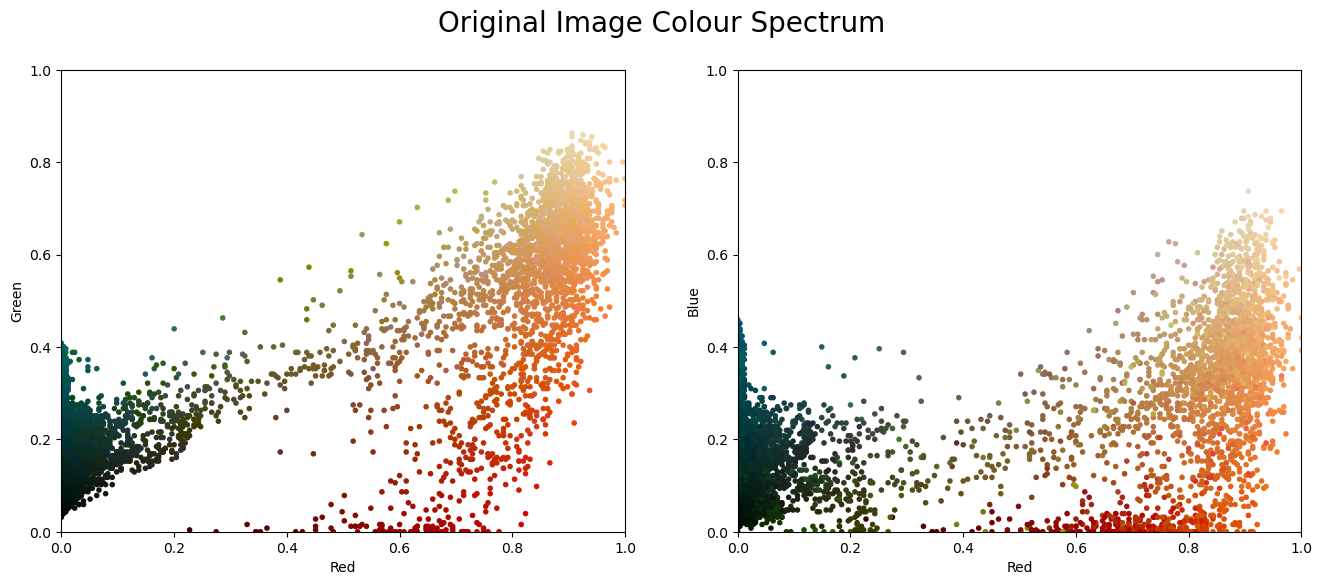

In [47]:
plot_pixels(data, title='Original Image Colour Spectrum')

### Mini-batch K-means Clustering
The Mini-batch K-means clustering algorithm is a version of the K-means algorithm which can be used instead of the K-means algorithm when clustering on huge datasets. Sometimes it performs better than the standard K-means algorithm while working on huge datasets because it doesn’t iterate over the entire dataset. It creates random batches of data to be stored in memory, then a random batch of data is collected on each iteration to update the clusters.<br>
https://thecleverprogrammer.com/2021/09/10/mini-batch-k-means-clustering-in-machine-learning/

We are going to use MiniBatchKMeans to convert our images from a 24 bit colour image to a 4 bit colour image, which will only have 16 colours.

In [48]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

If we now try to graph our clustered data we get the following

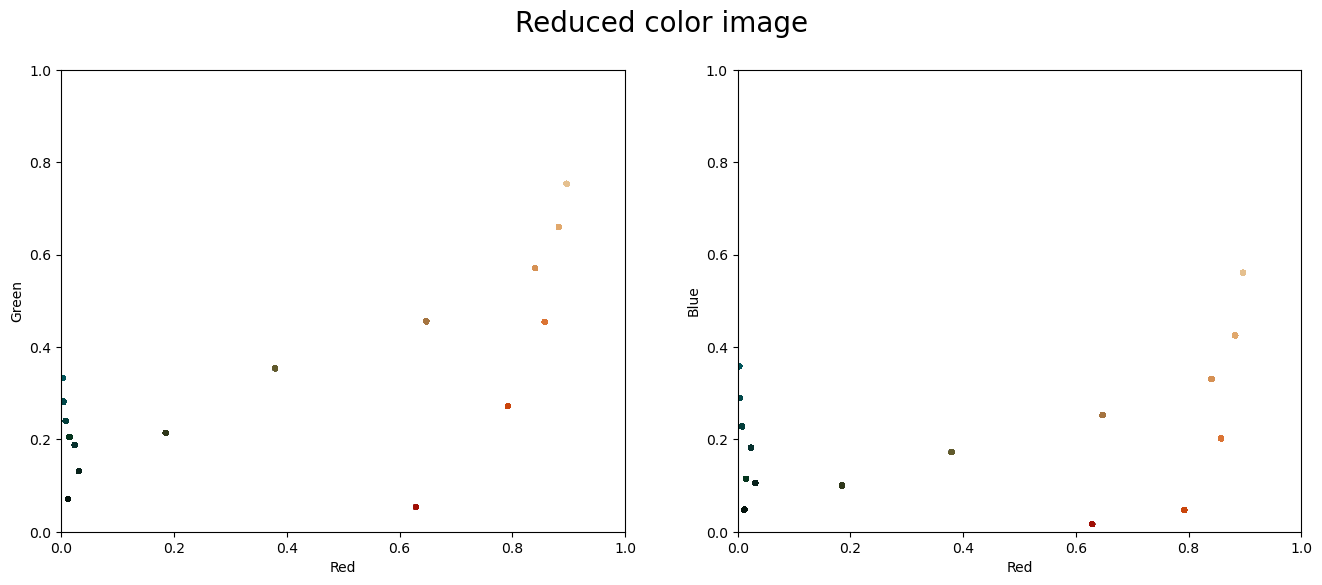

In [49]:
plot_pixels(new_colors, colors=new_colors, title="Reduced color image")

We now only see 16 points on our graph.  Or rather we see 10000 points clustered at 16 locations.  These are the centroid locations that were chosen by our k-Means model.  All the points have been recoloured to one of these 16 values.

Let's redraw our reduced colours, but we will use the original positions.  You will notice that the colours are still distributed the same, but we don't have the same colour tones.

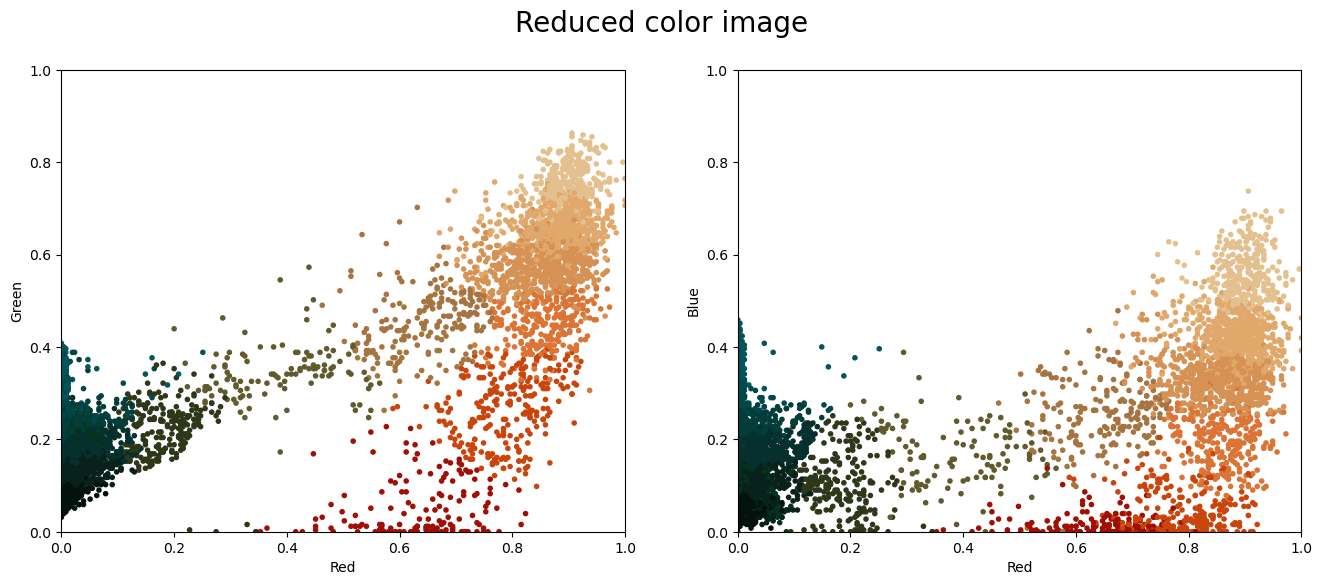

In [50]:
plot_pixels(data, colors=new_colors, title="Reduced color image")

We can plot our original image and our reduced colour image side by side.

Text(0.5, 1.0, '4-bit Image')

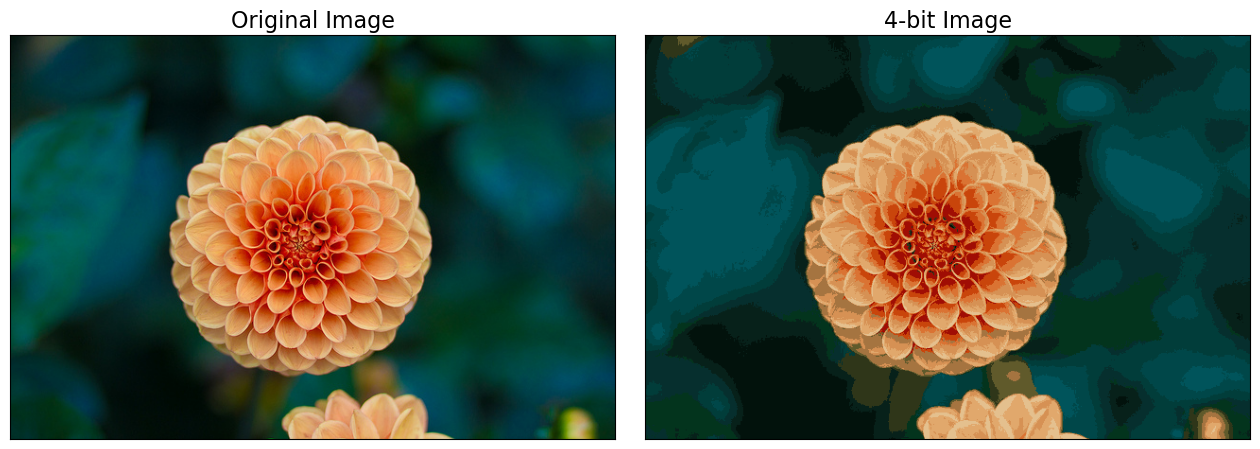

In [51]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw = dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)

ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)

ax[1].imshow(flower_recolored)
ax[1].set_title('4-bit Image', size=16)